# How wide does the response window actually need to be?

`LisaGB.__post_init__` sizes `response_points` from a **worst case**: the fastest chirp
the mass prior allows, evaluated at the top of the frequency band, plus the annual
doppler sideband, rounded up to a power of two. For the default two-year configuration
that lands on **1024 rFFT bins**.

This notebook asks the other question — *what does a source drawn from the priors
actually need?* — and follows the answer downstream, because `response_points` is the
head of a chain that ends in the attention memory of the network:

$$
\texttt{response\_points} \;\longrightarrow\; \texttt{window\_bins}
\;\longrightarrow\; \text{WDM image} \;\longrightarrow\; \text{tokens}
\;\longrightarrow\; \text{attention logits} \propto \text{tokens}^2
$$

**What comes out (all computed below):**

1. **The median source spans 14 bins.** The code allocates 1024 for every one of them.
2. **99.43% of draws fit inside `MIN_RESPONSE_POINTS = 256`**, so for almost the whole
   prior the physics never binds — the floor does. The 256 → 1024 gap is bought entirely
   for the last 0.6%. The reference ladder runs down to 1 so the sub-floor rungs show
   where the prior really sits: **67% of draws fit in 32 bins, 81% in 64, 92% in 128**,
   and crossing any of them changes no allocation, which is the point.
3. **The worst case is a corner the prior essentially never visits**: it pairs
   $M_c = 1.22\,M_\odot$ (an equal-mass $1.4+1.4$ pair, the extreme edge of `mass_range`)
   with $f_0 = 12$ mHz, while the sampled $M_c$ concentrates near $0.43\,M_\odot$. In the
   $(f_0, M_c)$ plane the `span = 256` contour only dips into the prior above $\sim9$ mHz.
4. **`span` is set by $f_0$, not by the mass.** With $\dot f \propto M_c^{5/3} f_0^{11/3}$
   the frequency exponent dominates: binned by $f_0$ the span climbs three decades, binned
   by $M_c$ it is almost flat.
5. **Downstream this is a factor of 16 in attention memory.** `response_points` 1024 → 512
   still covers 99.999% of draws and permits a window half as wide, which is 4× fewer
   tokens and **32.1 GiB → 8.1 GiB** of attention logits at `batch_size=256`.

The last point is a *permission*, not a recommendation: `window_bins` also sets how
crowded the `n_sources` sources are in the window, so shrinking it changes the confusion
problem being learned, not only its cost.

In [1]:
%matplotlib inline

import warnings

warnings.filterwarnings("ignore")

import math

import equinox as eqx
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import BoundaryNorm, ListedColormap

# importing canna already sets jax_enable_x64; the LISA band needs float64 end to end
from canna.lisa import LisaGB
from canna.lisa.problem import MIN_RESPONSE_POINTS
from canna.lisa.priors import chirp_mass_from_fdot, fdot_from_chirp_mass
from canna.lisa.constants import EARTH_ORBIT_SPEED, SPEED_OF_LIGHT

N_DRAWS = 200_000

# `needed` can only ever take these values -- MIN_RESPONSE_POINTS floors it at 256
LEVELS = np.array([256, 512, 1024, 2048])
CMAP = ListedColormap(["#4C72B0", "#55A868", "#C44E52", "#8172B2"])
NORM = BoundaryNorm([128, 384, 768, 1536, 3072], CMAP.N)

# raw `span`, though, lives well below that floor -- the median is 14 bins -- so the
# reference lines run lower than the allocation ever does. The sub-floor ones are drawn
# grey and dotted precisely because crossing them changes nothing: a source spanning 64
# bins and one spanning 8 are both handed 256.
SPAN_LEVELS = 2 ** np.arange(12)  # 1 ... 2048

# a light-to-dark grey ramp, so the eye reads the ladder climbing towards the floor
_SUBFLOOR = [lvl for lvl in SPAN_LEVELS if lvl < MIN_RESPONSE_POINTS]
SUBFLOOR_COLOURS = {
    lvl: str(round(0.74 - 0.54 * i / (len(_SUBFLOOR) - 1), 3))
    for i, lvl in enumerate(_SUBFLOOR)
}


def span_line(level):
    """Colour and linestyle for a `span` reference line."""
    if level < MIN_RESPONSE_POINTS:
        return SUBFLOOR_COLOURS[level], ":"
    return CMAP.colors[int(np.log2(level)) - 8], "--"

# response_points=None is the default: __post_init__ fills it from the worst case
problem = LisaGB(response_points=None)
T_OBS = problem.t_obs
V_OVER_C = EARTH_ORBIT_SPEED / SPEED_OF_LIGHT
F_LO, F_HI = problem.f0_range

print(f"t_obs            = {T_OBS:.6e} s  ({T_OBS / (365.25 * 86400):.3f} yr)")
print(f"f0_range         = {problem.f0_range}")
print(f"mass_range       = {problem.mass_range}")
print(f"chirp_mass_range = ({problem.chirp_mass_range[0]:.6f}, "
      f"{problem.chirp_mass_range[1]:.6f}) Msun")
print(f"v_earth / c      = {V_OVER_C:.6e}")

t_obs            = 6.311520e+07 s  (2.000 yr)
f0_range         = (0.0001, 0.012)
mass_range       = (0.15, 1.4)
chirp_mass_range = (0.130583, 1.218771) Msun
v_earth / c      = 9.935207e-05


## 0. What the code computes

Reproducing `__post_init__` line by line, so the worst case is not taken on trust:

```python
drift   = self.fdot_range[1] * self.t_obs
doppler = self.f0_range[1] * EARTH_ORBIT_SPEED / SPEED_OF_LIGHT
span    = 2 * math.ceil((doppler + drift) * self.t_obs)
needed  = 1 << (max(span, MIN_RESPONSE_POINTS) - 1).bit_length()
```

Note `fdot_range[1]` is itself a joint extreme — `fdot_from_chirp_mass` evaluated at the
**largest** chirp mass *and* the **highest** frequency at once.

In [2]:
drift_wc = problem.fdot_range[1] * T_OBS
doppler_wc = F_HI * V_OVER_C
span_wc = 2 * math.ceil((doppler_wc + drift_wc) * T_OBS)
needed_wc = 1 << (max(span_wc, MIN_RESPONSE_POINTS) - 1).bit_length()

print(f"fdot_range              = ({problem.fdot_range[0]:.6e}, "
      f"{problem.fdot_range[1]:.6e}) Hz/s")
print(f"drift   = fdot_hi*t_obs = {drift_wc:.6e} Hz    "
      f"({100 * drift_wc / (drift_wc + doppler_wc):.1f}% of the half-span)")
print(f"doppler = f0_hi*v/c     = {doppler_wc:.6e} Hz    "
      f"({100 * doppler_wc / (drift_wc + doppler_wc):.1f}%)")
print(f"(drift + doppler)*t_obs = {(drift_wc + doppler_wc) * T_OBS:.6f} bins")
print(f"span                    = {span_wc}")
print(f"needed                  = {needed_wc}")
print()
assert problem.response_points == needed_wc
print(f"problem.response_points = {problem.response_points}  (assigned from needed)")
print(f"problem.window_bins     = {problem.window_bins}  "
      f"-> the response is {100 * problem.response_points / problem.window_bins:.1f}% "
      f"of the window")

fdot_range              = (4.198665e-23, 7.303041e-14) Hz/s
drift   = fdot_hi*t_obs = 4.609329e-06 Hz    (79.4% of the half-span)
doppler = f0_hi*v/c     = 1.192225e-06 Hz    (20.6%)
(drift + doppler)*t_obs = 366.166221 bins
span                    = 734
needed                  = 1024

problem.response_points = 1024  (assigned from needed)
problem.window_bins     = 4096  -> the response is 25.0% of the window


## 1. What the priors actually need

`sample_physical` draws $f_0$ log-uniformly inside the window, and `sample_f` slides the
window log-uniformly across the band, so the marginal over $f_0$ is log-uniform on
`f0_range`. The chirp mass comes from the `ChirpMass` prior itself (Korol et al. 2022),
and $\dot f$ is not free — it is what $(M_c, f_0)$ imply.

Each source then gets **its own** doppler and drift, rather than the band maximum.

In [3]:
key_f, key_m = jr.split(jr.key(0))

# f0: log-uniform on f0_range, the marginal the sliding window induces
u = jr.uniform(key_f, (N_DRAWS,))
f0 = np.asarray(F_LO * (F_HI / F_LO) ** u)

# chirp mass: the actual prior object, not an approximation of it
mc = np.asarray(
    eqx.filter_vmap(problem.chirp_mass_prior)(jr.split(key_m, N_DRAWS))
).ravel()
fdot = np.asarray(fdot_from_chirp_mass(jnp.asarray(mc), jnp.asarray(f0)))


def span_of(f0, fdot):
    """The per-source version of __post_init__'s span."""
    return 2 * np.ceil((f0 * V_OVER_C + fdot * T_OBS) * T_OBS)


def needed_of(span):
    """max(span, MIN_RESPONSE_POINTS) rounded up to a power of two."""
    floored = np.maximum(span, MIN_RESPONSE_POINTS).astype(np.int64)
    return np.left_shift(1, np.ceil(np.log2(floored)).astype(np.int64))


span = span_of(f0, fdot)
needed = needed_of(span)

print(f"{N_DRAWS:,} draws")
print(f"  chirp mass  median = {np.median(mc):.3f} Msun   max = {mc.max():.3f}   "
      f"(prior support up to {problem.chirp_mass_range[1]:.3f})")
print(f"  span        min / median / max = {span.min():.0f} / "
      f"{np.median(span):.0f} / {span.max():.0f}")
print(f"  span        99th / 99.9th pct  = {np.percentile(span, 99):.0f} / "
      f"{np.percentile(span, 99.9):.0f}")
print(f"  worst case used by the code    = {span_wc}  ->  {needed_wc}")
print()
print("  where the raw span falls -- the ladder runs well below the 256 floor:")
for level in SPAN_LEVELS:
    mark = "   (floor)" if level == MIN_RESPONSE_POINTS else ""
    print(f"    span <= {level:>5} : {100 * np.mean(span <= level):8.4f}%{mark}")
print()
print("  what the code would allocate, per source:")
for level in LEVELS:
    print(f"    needed == {level:>5} : {100 * np.mean(needed == level):7.3f}%")
print()
print(f"  the median source spans {np.median(span):.0f} bins; the code allocates "
      f"{needed_wc} for every one -> {needed_wc / np.median(span):.0f}x")

200,000 draws
  chirp mass  median = 0.432 Msun   max = 1.182   (prior support up to 1.219)
  span        min / median / max = 2 / 14 / 558
  span        99th / 99.9th pct  = 240 / 300
  worst case used by the code    = 734  ->  1024

  where the raw span falls -- the ladder runs well below the 256 floor:
    span <=     1 :   0.0000%
    span <=     2 :   9.7535%
    span <=     4 :  24.1095%
    span <=     8 :  38.5615%
    span <=    16 :  53.0260%
    span <=    32 :  67.2660%
    span <=    64 :  80.7830%
    span <=   128 :  91.9750%
    span <=   256 :  99.4295%   (floor)
    span <=   512 :  99.9990%
    span <=  1024 : 100.0000%
    span <=  2048 : 100.0000%

  what the code would allocate, per source:
    needed ==   256 :  99.430%
    needed ==   512 :   0.570%
    needed ==  1024 :   0.001%
    needed ==  2048 :   0.000%

  the median source spans 14 bins; the code allocates 1024 for every one -> 73x


## 2. The distribution

Left: what sources actually span, against the power-of-two ladder and the worst case.
Right: `needed` after the floor and the rounding — i.e. what the code *would* allocate if
it sized itself per source.

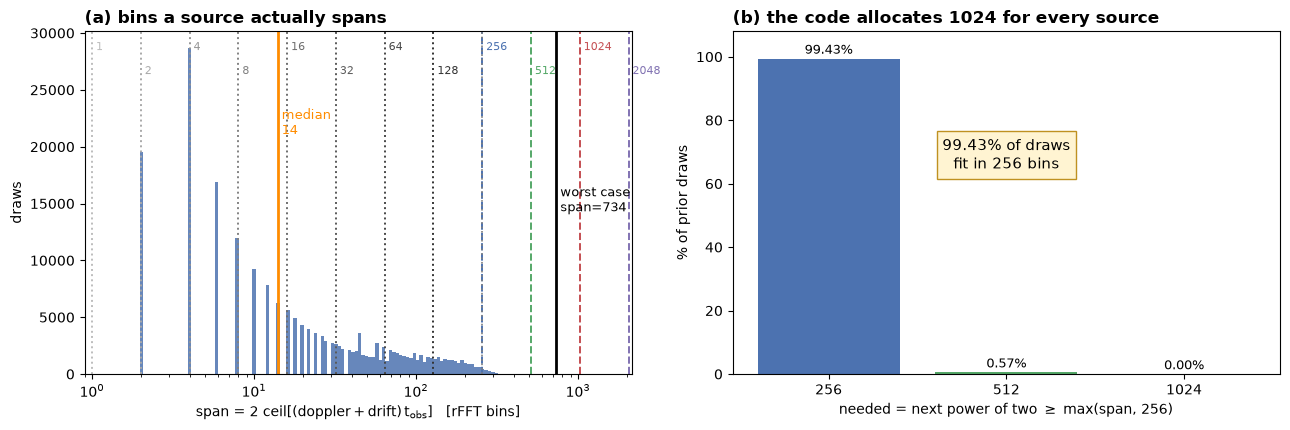

In [4]:
fig, (ax_span, ax_need) = plt.subplots(1, 2, figsize=(13, 4.4))

bins = np.logspace(0.0, np.log10(span_wc * 1.15), 140)   # from 1, so the whole ladder fits
ax_span.hist(span, bins=bins, color="#4C72B0", alpha=0.85)
top = ax_span.get_ylim()[1]
for i, level in enumerate(SPAN_LEVELS):
    colour, ls = span_line(level)
    ax_span.axvline(level, color=colour, ls=ls, lw=1.4)
    # stagger, or the low end of the ladder overlaps itself
    ax_span.text(level, top * (0.97 if i % 2 == 0 else 0.90), f" {level}", color=colour,
                 fontsize=8, va="top")
ax_span.set_xlim(left=0.9)
ax_span.axvline(span_wc, color="k", lw=2)
ax_span.text(span_wc, ax_span.get_ylim()[1] * 0.55, f" worst case\n span={span_wc}",
             fontsize=9, va="top")
ax_span.axvline(MIN_RESPONSE_POINTS, color="grey", ls=":", lw=1.2)
ax_span.axvline(np.median(span), color="darkorange", lw=2)
ax_span.text(np.median(span), ax_span.get_ylim()[1] * 0.78,
             f" median\n {np.median(span):.0f}", color="darkorange", fontsize=9, va="top")
ax_span.set_xscale("log")
ax_span.set_xlabel(r"span = 2 ceil[$(\rm doppler + drift)\,t_{obs}$]   [rFFT bins]")
ax_span.set_ylabel("draws")
ax_span.set_title("(a) bins a source actually spans", loc="left", fontweight="bold")

values, counts = np.unique(needed, return_counts=True)
frac = 100 * counts / counts.sum()
bars = ax_need.bar([str(v) for v in values], frac,
                   color=[CMAP.colors[int(np.log2(v)) - 8] for v in values])
for bar, f_pct in zip(bars, frac):
    ax_need.text(bar.get_x() + bar.get_width() / 2, f_pct + 1.5, f"{f_pct:.2f}%",
                 ha="center", fontsize=9.5)
ax_need.set_ylim(0, 108)
ax_need.set_xlabel(r"needed = next power of two $\geq$ max(span, 256)")
ax_need.set_ylabel("% of prior draws")
ax_need.set_title(f"(b) the code allocates {needed_wc} for every source",
                  loc="left", fontweight="bold")
ax_need.text(0.5, 0.60, f"{100 * np.mean(needed <= 256):.2f}% of draws\nfit in 256 bins",
             transform=ax_need.transAxes, ha="center", fontsize=11,
             bbox=dict(fc="#FFF3CD", ec="#B8860B", alpha=0.9))

fig.tight_layout()
plt.show()

## 3. Where the worst case sits, in $(f_0, M_c)$

$M_c$ and $f_0$ are the quantities actually drawn — $\dot f$ is neither sampled nor free,
it is what `fdot_from_chirp_mass` makes of the pair. Plotting in these coordinates the
prior is simply a **horizontal band**: $M_c$ is drawn independently of $f_0$, so the
support is the same at every frequency and the whole structure sits in the contours.

Inverting $\texttt{span} = L$ for the chirp mass with `chirp_mass_from_fdot` gives

$$
M_c^{(L)}(f_0) \;=\; \texttt{chirp\_mass\_from\_fdot}\!\left(
\frac{L / (2 t_{obs}) - f_0 v/c}{t_{obs}},\; f_0 \right),
$$

a steeply falling curve ($\dot f \propto f_0^{11/3}$ inverts to $M_c \propto f_0^{-11/5}$
at fixed span). A source needs more than $L$ bins only if it lies **above** the $L$ curve.

The point of the plot: the `span = 256` contour stays far above the prior ceiling across
almost the whole band, and only crosses into the shaded support in the last decade — which
is precisely the 0.57% of draws that need more than the floor. The star is the corner
`__post_init__` sizes for, at the top-right of the support.

The ladder is drawn all the way down to 1. Everything **below 256 is grey and dotted**,
because crossing those lines changes nothing: `MIN_RESPONSE_POINTS` floors the allocation
at 256, so a source spanning 8 bins and one spanning 200 are handed the same buffer. They
are where the prior actually lives all the same — the median draw sits at 14 bins, below
all but the lowest three rungs.

`span = 1` is drawn for completeness but is **unreachable by construction**: `span` is
$2\lceil\cdot\rceil$, hence always even, and the smallest value in 200,000 draws is 2.
The coverage table says so directly, with 0.0000% at that rung.

Each sub-floor contour **stops dead** at

$$f_0 \;=\; \frac{L}{2\,t_{obs}\,v/c},$$

where the annual doppler sideband alone fills the level. Past that frequency no chirp
mass, however small, keeps a source inside $L$ bins — which is why the curves plunge
vertically instead of continuing right. Those vertical walls are the doppler floor made
visible, and because the cut-off is **linear in $L$**, each doubling of the rung doubles
the frequency at which it falls: the walls march right in even steps on the log axis. It
is the doppler, not the chirp, that stops `span` from ever getting small at high $f_0$ —
even though it is the chirp that dominates the worst case at the top of the band.

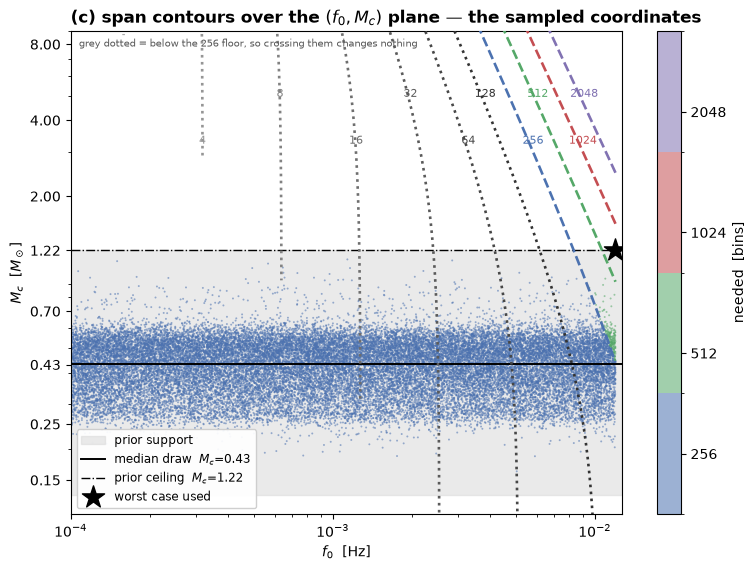

In [5]:
fig, ax = plt.subplots(figsize=(7.8, 5.8))

mc_lo, mc_hi = problem.chirp_mass_range

# the prior support is a horizontal band: Mc is drawn independently of f0
ax.axhspan(mc_lo, mc_hi, color="0.85", alpha=0.55, zorder=0,
           label="prior support")

step = max(1, N_DRAWS // 30_000)
scatter = ax.scatter(f0[::step], mc[::step], c=needed[::step], cmap=CMAP, norm=NORM,
                     s=2, alpha=0.55, linewidths=0, zorder=2)

grid_f = np.logspace(np.log10(F_LO), np.log10(F_HI), 4000)
# two alternating lanes above the data: the contours bunch up at the top of the
# ladder, and staggering separates neighbours vertically as well as horizontally
LABEL_LANES = (3.0, 4.6)
for rung, level in enumerate(SPAN_LEVELS):
    colour, ls = span_line(level)
    # span = level  <=>  fdot = (level / (2 t_obs) - f0 v/c) / t_obs,
    # inverted onto the chirp mass the prior actually draws
    fdot_c = (level / (2 * T_OBS) - grid_f * V_OVER_C) / T_OBS

    # the contour simply stops where the doppler sideband alone fills the level: past
    # f0 = level / (2 t_obs v/c) no chirp mass, however small, keeps a source inside it
    visible = fdot_c > 0
    if not visible.any():
        continue
    mc_c = np.asarray(
        chirp_mass_from_fdot(jnp.asarray(fdot_c[visible]), jnp.asarray(grid_f[visible]))
    )
    ax.plot(grid_f[visible], mc_c, color=colour, lw=1.9, ls=ls, zorder=3)

    # mc_c falls monotonically with f0, so every contour crosses one horizontal lane
    # exactly once, and in ladder order -- label them all there and nothing collides
    lane = LABEL_LANES[rung % 2]
    crossing = np.nonzero(mc_c < lane)[0]
    if crossing.size:
        j = crossing[0]
        ax.text(grid_f[visible][j], lane * 1.05, f"{level}", color=colour,
                fontsize=8, va="bottom", ha="center", zorder=4)

ax.axhline(np.median(mc), color="k", lw=1.4, ls="-",
           label=rf"median draw  $M_c$={np.median(mc):.2f}")
ax.axhline(mc_hi, color="k", lw=1.0, ls="-.",
           label=rf"prior ceiling  $M_c$={mc_hi:.2f}")
ax.scatter([F_HI], [mc_hi], marker="*", s=280, color="k", zorder=5,
           label="worst case used")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(F_LO, F_HI * 1.06)         # a sliver of margin so the star is not clipped
ax.set_ylim(0.11, 9.0)                 # headroom above the data for the label lanes
ax.set_yticks([0.15, 0.25, 0.43, 0.7, 1.22, 2.0, 4.0, 8.0])
ax.yaxis.set_major_formatter(plt.ScalarFormatter())
ax.yaxis.set_minor_formatter(plt.NullFormatter())   # drop the 2x10^-1 clutter
ax.set_xlabel(r"$f_0$  [Hz]")
ax.set_ylabel(r"$M_c$  [$M_\odot$]")
ax.legend(fontsize=8.5, loc="lower left", framealpha=0.93)
ax.set_title(r"(c) span contours over the $(f_0, M_c)$ plane — the sampled coordinates",
             loc="left", fontweight="bold")
ax.text(0.015, 0.985, "grey dotted = below the 256 floor, so crossing them changes nothing",
        transform=ax.transAxes, fontsize=7.5, va="top", color="0.35")
fig.colorbar(scatter, ax=ax, ticks=LEVELS).set_label("needed  [bins]")

fig.tight_layout()
plt.show()

## 4. Which of the two actually sets the span

Now that both sampled variables are on the table, bin by each in turn. The frequency
exponent (11/3) beats the mass exponent (5/3), and the priors amplify the gap further:
$f_0$ ranges over two decades while $M_c$ spans less than one, and log-uniformly rather
than concentrated.

**Left:** binned by $f_0$, the span climbs from 2 to ~250 bins — three decades — and the
median, 99th percentile and maximum sit nearly on top of each other, so the mass spread
adds almost no width. **Right:** binned by $M_c$, the median is flat to within a factor of
a few across the whole support.

`response_points` is therefore a statement about the top of the frequency band, and
`mass_range` barely enters — even though it is `mass_range[1]` that sets the worst case.

span median, lowest vs highest f0 bin : 2  ->  234   (117x)
span median, lowest vs highest Mc bin : 8  ->  12   (2x)


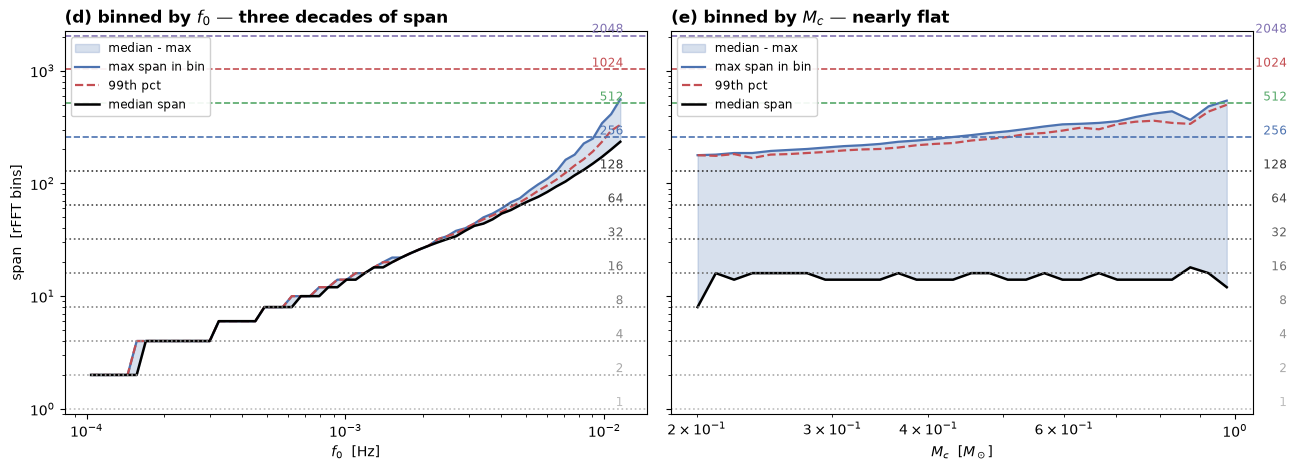

In [6]:
def binned_span(values, edges):
    """Median / 99th / max of span in each bin of `values`."""
    index = np.digitize(values, edges) - 1
    centres, q50, q99, qmax = [], [], [], []
    for i in range(len(edges) - 1):
        mask = index == i
        if mask.sum() < 30:
            continue
        centres.append(np.sqrt(edges[i] * edges[i + 1]))
        q50.append(np.percentile(span[mask], 50))
        q99.append(np.percentile(span[mask], 99))
        qmax.append(span[mask].max())
    return np.array(centres), np.array(q50), np.array(q99), np.array(qmax)


f_centres, f50, f99, fmax = binned_span(
    f0, np.logspace(np.log10(F_LO), np.log10(F_HI), 60)
)
m_centres, m50, m99, mmax = binned_span(
    mc, np.logspace(np.log10(mc.min()), np.log10(mc.max()), 40)
)

fig, (ax_f, ax_m) = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True)

for ax, centres, q50, q99, qmax, xlabel, title in (
    (ax_f, f_centres, f50, f99, fmax, r"$f_0$  [Hz]",
     r"(d) binned by $f_0$ — three decades of span"),
    (ax_m, m_centres, m50, m99, mmax, r"$M_c$  [$M_\odot$]",
     r"(e) binned by $M_c$ — nearly flat"),
):
    ax.fill_between(centres, q50, qmax, color="#4C72B0", alpha=0.22,
                    label="median - max")
    ax.plot(centres, qmax, color="#4C72B0", lw=1.6, label="max span in bin")
    ax.plot(centres, q99, color="#C44E52", lw=1.6, ls="--", label="99th pct")
    ax.plot(centres, q50, color="k", lw=1.8, label="median span")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(xlabel)
    ax.set_title(title, loc="left", fontweight="bold")
    ax.legend(fontsize=8.5, loc="upper left", framealpha=0.92)

ax_f.set_ylabel("span  [rFFT bins]")
ax_f.set_ylim(0.9, max(fmax.max() * 4, 600))   # down to 1, so the whole ladder shows
for ax, right in ((ax_f, F_HI), (ax_m, mc.max())):
    for level in SPAN_LEVELS:
        if level > ax_f.get_ylim()[1]:
            continue
        colour, ls = span_line(level)
        ax.axhline(level, color=colour, ls=ls, lw=1.2)
        ax.text(right * 0.99, level * 1.06, f"{level}", color=colour, fontsize=8.5,
                ha="right")

print(f"span median, lowest vs highest f0 bin : {f50[0]:.0f}  ->  {f50[-1]:.0f}"
      f"   ({f50[-1] / f50[0]:.0f}x)")
print(f"span median, lowest vs highest Mc bin : {m50[0]:.0f}  ->  {m50[-1]:.0f}"
      f"   ({m50[-1] / m50[0]:.0f}x)")

fig.tight_layout()
plt.show()

## 5. What the worst case costs downstream

`response_points` is not a local choice. `__post_init__` asserts

```python
assert self.window_bins > 2 * self.response_points
```

and `window_bins = wdm_freq_bands * (wdm_times // 2)`, so a wider response forces a wider
window, a larger WDM image, more patch tokens — and attention is **quadratic** in tokens.

The table below holds `wdm_times = 32` and `patch_stages = 1` (config `B`) and varies only
`response_points`, taking the smallest power-of-two `wdm_freq_bands` the assert permits.
Coverage is measured against the prior draws above.

In [7]:
BATCH, HEADS, N_SOURCES, PATCH = 256, 8, problem.n_sources, problem.patch_downsample
WDM_TIMES = problem.wdm_times

print(f"{'resp_pts':>9} {'coverage':>10} {'wdm_freq':>9} {'window':>8} "
      f"{'image':>10} {'tokens':>7} {'logits GiB':>11} {'vs now':>7}")
print("-" * 80)

reference = None
for resp in (1024, 512, 256):
    coverage = 100 * np.mean(span <= resp)

    # smallest power-of-two wdm_freq_bands with wdm_freq_bands * wdm_times//2 > 2*resp
    freq_bands = 1
    while freq_bands * (WDM_TIMES // 2) <= 2 * resp:
        freq_bands *= 2

    window_bins = freq_bands * (WDM_TIMES // 2)
    height, width = WDM_TIMES // PATCH, freq_bands // PATCH
    tokens = height * width + N_SOURCES
    logits_gib = BATCH * HEADS * tokens**2 * 4 / 1024**3
    reference = reference or logits_gib

    print(f"{resp:>9} {coverage:>9.3f}% {freq_bands:>9} {window_bins:>8} "
          f"{str(WDM_TIMES) + 'x' + str(freq_bands):>10} {tokens:>7} "
          f"{logits_gib:>11.2f} {reference / logits_gib:>6.1f}x")

print()
print("logits GiB = batch * heads * tokens^2 * 4B, the f32 matrix the xla attention")
print("path materialises; it is the term that decides whether a batch fits on the card.")

 resp_pts   coverage  wdm_freq   window      image  tokens  logits GiB  vs now
--------------------------------------------------------------------------------
     1024   100.000%       256     4096     32x256    2052       32.13    1.0x
      512    99.999%       128     2048     32x128    1028        8.06    4.0x
      256    99.430%        64     1024      32x64     516        2.03   15.8x

logits GiB = batch * heads * tokens^2 * 4B, the f32 matrix the xla attention
path materialises; it is the term that decides whether a batch fits on the card.


## Conclusion

`response_points = 1024` is sized for a source the prior effectively never produces. The
median draw spans **14 bins**, 99.43% fit inside the `MIN_RESPONSE_POINTS = 256` floor,
and the largest span in 200,000 draws is 558.

Dropping to **512 covers 99.999%** of the prior while permitting a window half as wide,
which is 4× fewer tokens and **4× less attention memory**. Two caveats keep this from
being automatic:

* **Truncation is not free.** A source whose span exceeds `response_points` has its
  sidebands clipped by `jaxgb`. At 512 that is roughly 1 draw in 100,000; at 256 it is
  1 in 175, which is likely too many.
* **`window_bins` is a modelling choice, not only a buffer.** A narrower window packs the
  same `n_sources` into a narrower band and so raises source confusion. The table gives
  the *minimum* window the assert allows, not the one the science wants.

The honest reading: the 1024 is defensible as a safe bound, but it is paid for at every
training step, quadratically, and 512 buys back a factor of four for one source in
$10^5$.